In [51]:
import pandas as pd
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix
# Чтобы отображались все столбцы и строки (при необходимости можно ограничить строки)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)  # можно увеличить при необходимости
pd.set_option('display.width', 200)
pd.set_option('display.precision', 3)  # округление чисел до 3 знаков


In [ ]:
df = pd.read_csv('data/processed/Features_full.csv')
df.head()

,scenario,label,src_port,dst_port,mean_src,mean_dst,qty_src,pld_src,var_data,var_src,frst_src,scd_src,frst_dst,scd_dst,max_src,min_src,max_dst,ttl_src,duration,flowPktsPerSecond,flowBytesPerSecond,mean_flowiat,std_flowiat,min_flowiat,max_flowiat,packet_size_mean,packet_size_std,total_fiat,total_biat,min_fiat,max_fiat,mean_fiat,min_biat,max_biat,mean_biat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle
0,1,Non-VPN,55296.0,20660.0,32.0,0.0,3,96.0,0.000,0.0,32.0,32.0,0.0,0.0,32.0,32.0,0.0,128,3.021,0.993,31.782,1.510,0.708,1.010,2.011,32.0,0.000,3.021,0.000,1.010,2.011,1.510,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.010,1.510,2.011,0.708
1,1,Non-VPN,57140.0,20660.0,32.0,0.0,3,96.0,0.000,0.0,32.0,32.0,0.0,0.0,32.0,32.0,0.0,128,3.035,0.988,31.630,1.518,0.718,1.010,2.025,32.0,0.000,3.035,0.000,1.010,2.025,1.518,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.010,1.518,2.025,0.718
2,1,Non-VPN,57007.0,24674.0,32.0,0.0,3,96.0,0.000,0.0,32.0,32.0,0.0,0.0,32.0,32.0,0.0,128,3.015,0.995,31.839,1.508,0.700,1.012,2.003,32.0,0.000,3.015,0.000,1.012,2.003,1.508,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.012,1.508,2.003,0.700
3,1,Non-VPN,56883.0,60906.0,32.0,20.0,5,160.0,6.325,0.0,32.0,32.0,20.0,20.0,32.0,32.0,20.0,128,3.278,3.050,79.312,0.364,0.140,0.245,0.514,26.0,6.325,3.033,3.032,0.755,0.760,0.758,0.755,0.760,0.758,0.245,0.364,0.514,0.140,0.000,0.000,0.000,0.000
4,1,Non-VPN,57337.0,60906.0,32.0,20.0,5,160.0,6.325,0.0,32.0,32.0,20.0,20.0,32.0,32.0,20.0,128,3.301,3.029,78.766,0.367,0.138,0.249,0.517,26.0,6.325,3.051,3.050,0.759,0.767,0.763,0.757,0.766,0.762,0.249,0.367,0.517,0.138,0.000,0.000,0.000,0.000


In [53]:
df.describe()

,scenario,src_port,dst_port,mean_src,mean_dst,qty_src,pld_src,var_data,var_src,frst_src,scd_src,frst_dst,scd_dst,max_src,min_src,max_dst,ttl_src,duration,flowPktsPerSecond,flowBytesPerSecond,mean_flowiat,std_flowiat,min_flowiat,max_flowiat,packet_size_mean,packet_size_std,total_fiat,total_biat,min_fiat,max_fiat,mean_fiat,min_biat,max_biat,mean_biat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle
count,6596.000,6596.000,6596.000,6596.000,6596.000,6596.000,6.596e+03,6596.000,6195.000,6596.000,6596.000,6596.000,6596.000,6596.000,6596.000,6596.000,6596.000,6.596e+03,6.596e+03,6.596e+03,6.596e+03,6.143e+03,6.596e+03,6.596e+03,6596.000,6596.000,6596.000,6596.000,6.596e+03,6596.000,6596.000,6596.000,6596.000,6596.000,6.596e+03,6.596e+03,6.596e+03,5838.000,6596.000,6596.000,6596.000,6021.000
mean,4.858,53234.697,26105.008,89.993,138.744,107.569,6.337e+03,145.340,89.035,91.692,62.691,138.744,138.744,307.157,35.297,597.648,106.396,2.313e+01,6.246e+02,3.549e+04,3.204e+00,4.578e+00,1.120e+00,1.301e+01,129.097,145.340,22.750,12.318,1.227e+00,12.796,3.590,0.306,5.469,1.216,4.509e-02,7.146e-02,1.581e-01,0.043,4.265,6.833,12.946,4.508
std,3.452,6849.891,22077.476,162.429,438.776,1684.482,7.619e+04,385.980,239.239,303.257,204.447,438.776,438.776,925.117,17.726,3092.382,31.273,5.594e+01,4.310e+04,1.248e+06,9.094e+00,1.518e+01,5.078e+00,3.720e+01,260.492,385.980,55.274,41.814,3.682e+00,36.839,8.670,3.886,20.309,5.786,1.825e-01,1.920e-01,2.864e-01,0.089,14.628,16.985,37.225,16.209
min,1.000,137.000,1.000,19.444,0.000,1.000,2.100e+01,0.000,0.000,10.000,0.000,0.000,0.000,20.000,10.000,0.000,1.000,2.000e-06,6.291e-03,3.403e-01,3.333e-07,5.164e-07,0.000e+00,1.000e-06,19.444,0.000,0.000,0.000,0.000e+00,0.000,0.000,0.000,0.000,0.000,0.000e+00,0.000e+00,0.000e+00,0.000,0.000,0.000,0.000,0.000
25%,1.000,51413.000,2574.000,32.000,0.000,3.000,9.600e+01,0.000,0.000,32.000,28.000,0.000,0.000,32.000,28.000,0.000,64.000,2.207e+00,5.160e-01,3.156e+01,2.271e-01,2.569e-01,2.000e-05,5.129e-01,30.667,0.000,2.163,0.000,6.275e-05,0.563,0.284,0.000,0.000,0.000,0.000e+00,0.000e+00,0.000e+00,0.000,0.000,0.000,0.000,0.000
50%,6.000,54468.000,21994.000,32.000,0.000,3.000,9.600e+01,0.000,0.000,32.000,32.000,0.000,0.000,32.000,32.000,0.000,128.000,3.019e+00,9.965e-01,3.199e+01,1.504e+00,7.068e-01,9.993e-01,2.008e+00,32.000,0.000,3.017,0.000,1.000e+00,2.008,1.504,0.000,0.000,0.000,0.000e+00,4.268e-04,9.290e-04,0.000,1.011,1.509,2.008,0.704
75%,9.000,57178.250,50001.000,66.000,91.000,7.000,3.390e+02,78.235,41.500,40.000,32.000,91.000,91.000,111.000,32.000,136.000,128.000,9.374e+00,5.309e+00,7.493e+02,2.331e+00,1.969e+00,1.014e+00,6.078e+00,97.000,78.235,9.370,0.416,1.016e+00,6.077,3.534,0.000,0.230,0.042,2.700e-05,3.005e-02,1.351e-01,0.029,3.016,4.675,6.078,1.884
max,10.000,65432.000,65528.000,3731.710,10543.523,65111.000,2.797e+06,5758.050,6670.695,8385.000,5102.000,10543.523,10543.523,44768.000,217.000,65192.000,255.000,4.404e+02,3.500e+06,1.005e+08,3.179e+02,1.888e+02,3.179e+02,3.576e+02,4030.199,5758.050,440.424,431.002,1.222e+02,357.762,134.530,115.703,306.637,115.703,1.000e+00,1.000e+00,1.000e+00,0.691,317.905,317.905,357.566,186.161


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6596 entries, 0 to 6595
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   scenario            6596 non-null   int64  
 1   label               6596 non-null   object 
 2   src_port            6596 non-null   float64
 3   dst_port            6596 non-null   float64
 4   mean_src            6596 non-null   float64
 5   mean_dst            6596 non-null   float64
 6   qty_src             6596 non-null   int64  
 7   pld_src             6596 non-null   float64
 8   var_data            6596 non-null   float64
 9   var_src             6195 non-null   float64
 10  frst_src            6596 non-null   float64
 11  scd_src             6596 non-null   float64
 12  frst_dst            6596 non-null   float64
 13  scd_dst             6596 non-null   float64
 14  max_src             6596 non-null   float64
 15  min_src             6596 non-null   float64
 16  max_ds

# Кол-во пропусков

In [55]:
# Сколько пропущенных значений по каждому признаку
print(df.isna().sum().sort_values(ascending=False))


std_active            758
std_idle              575
std_flowiat           453
var_src               401
src_port                0
mean_dst                0
mean_src                0
qty_src                 0
dst_port                0
label                   0
scenario                0
frst_src                0
var_data                0
pld_src                 0
scd_src                 0
min_src                 0
max_dst                 0
scd_dst                 0
frst_dst                0
duration                0
flowPktsPerSecond       0
flowBytesPerSecond      0
mean_flowiat            0
min_flowiat             0
max_flowiat             0
ttl_src                 0
max_src                 0
packet_size_std         0
packet_size_mean        0
total_fiat              0
total_biat              0
mean_fiat               0
min_biat                0
min_fiat                0
max_fiat                0
mean_biat               0
max_biat                0
mean_active             0
min_active  

# Баланс классов

In [56]:
print(df['label'].value_counts())
print(df['scenario'].value_counts())


label
Non-VPN    5932
VPN         664
Name: count, dtype: int64
scenario
1     2538
9     1877
6      783
7      734
3      292
5      165
2      124
10      83
Name: count, dtype: int64


In [57]:
important_features = [
    'mean_idle',
    'mean_biat',
    'mean_fiat',
    'flowBytesPerSecond',
    'packet_size_std',
    'duration',
    'ttl_src',
    'pld_src',
    'flowPktsPerSecond',
    'packet_size_mean',
    'max_idle',
    'max_biat'
]


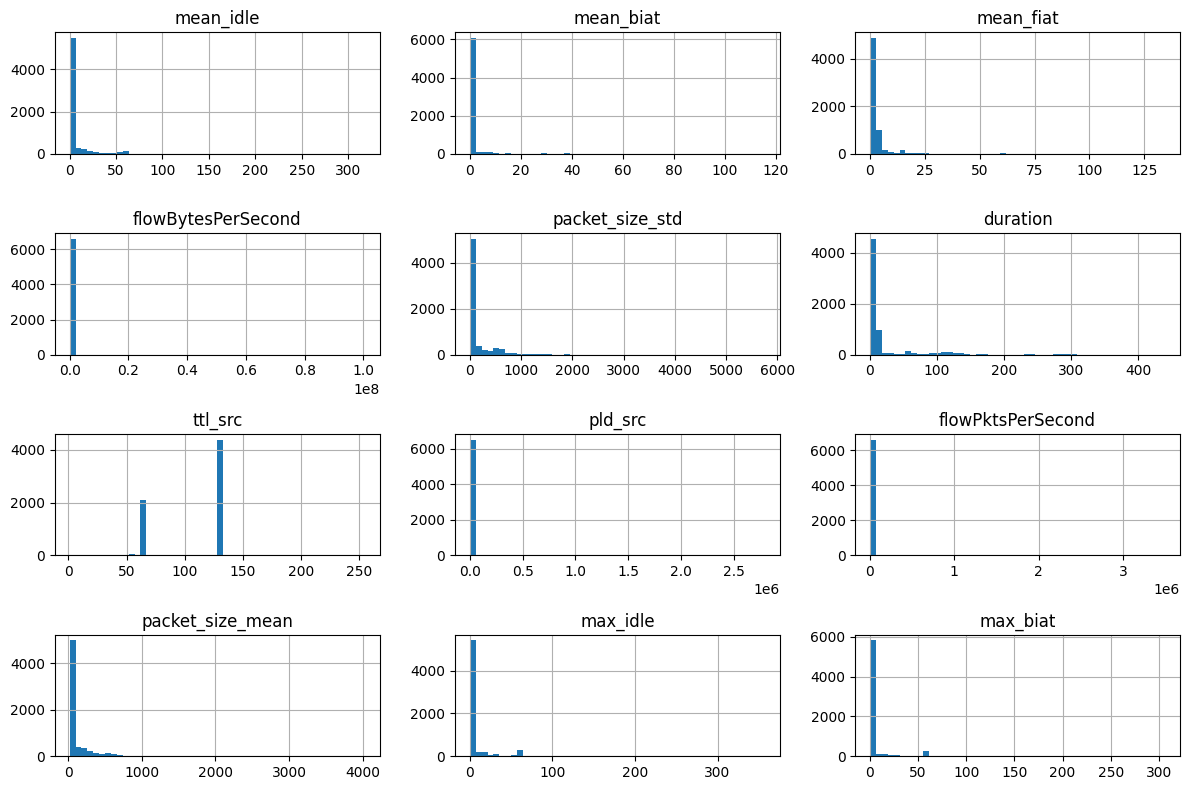

In [58]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns

# Построим распределения нескольких важных признаков
df[important_features].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()


# Корреляция признаков

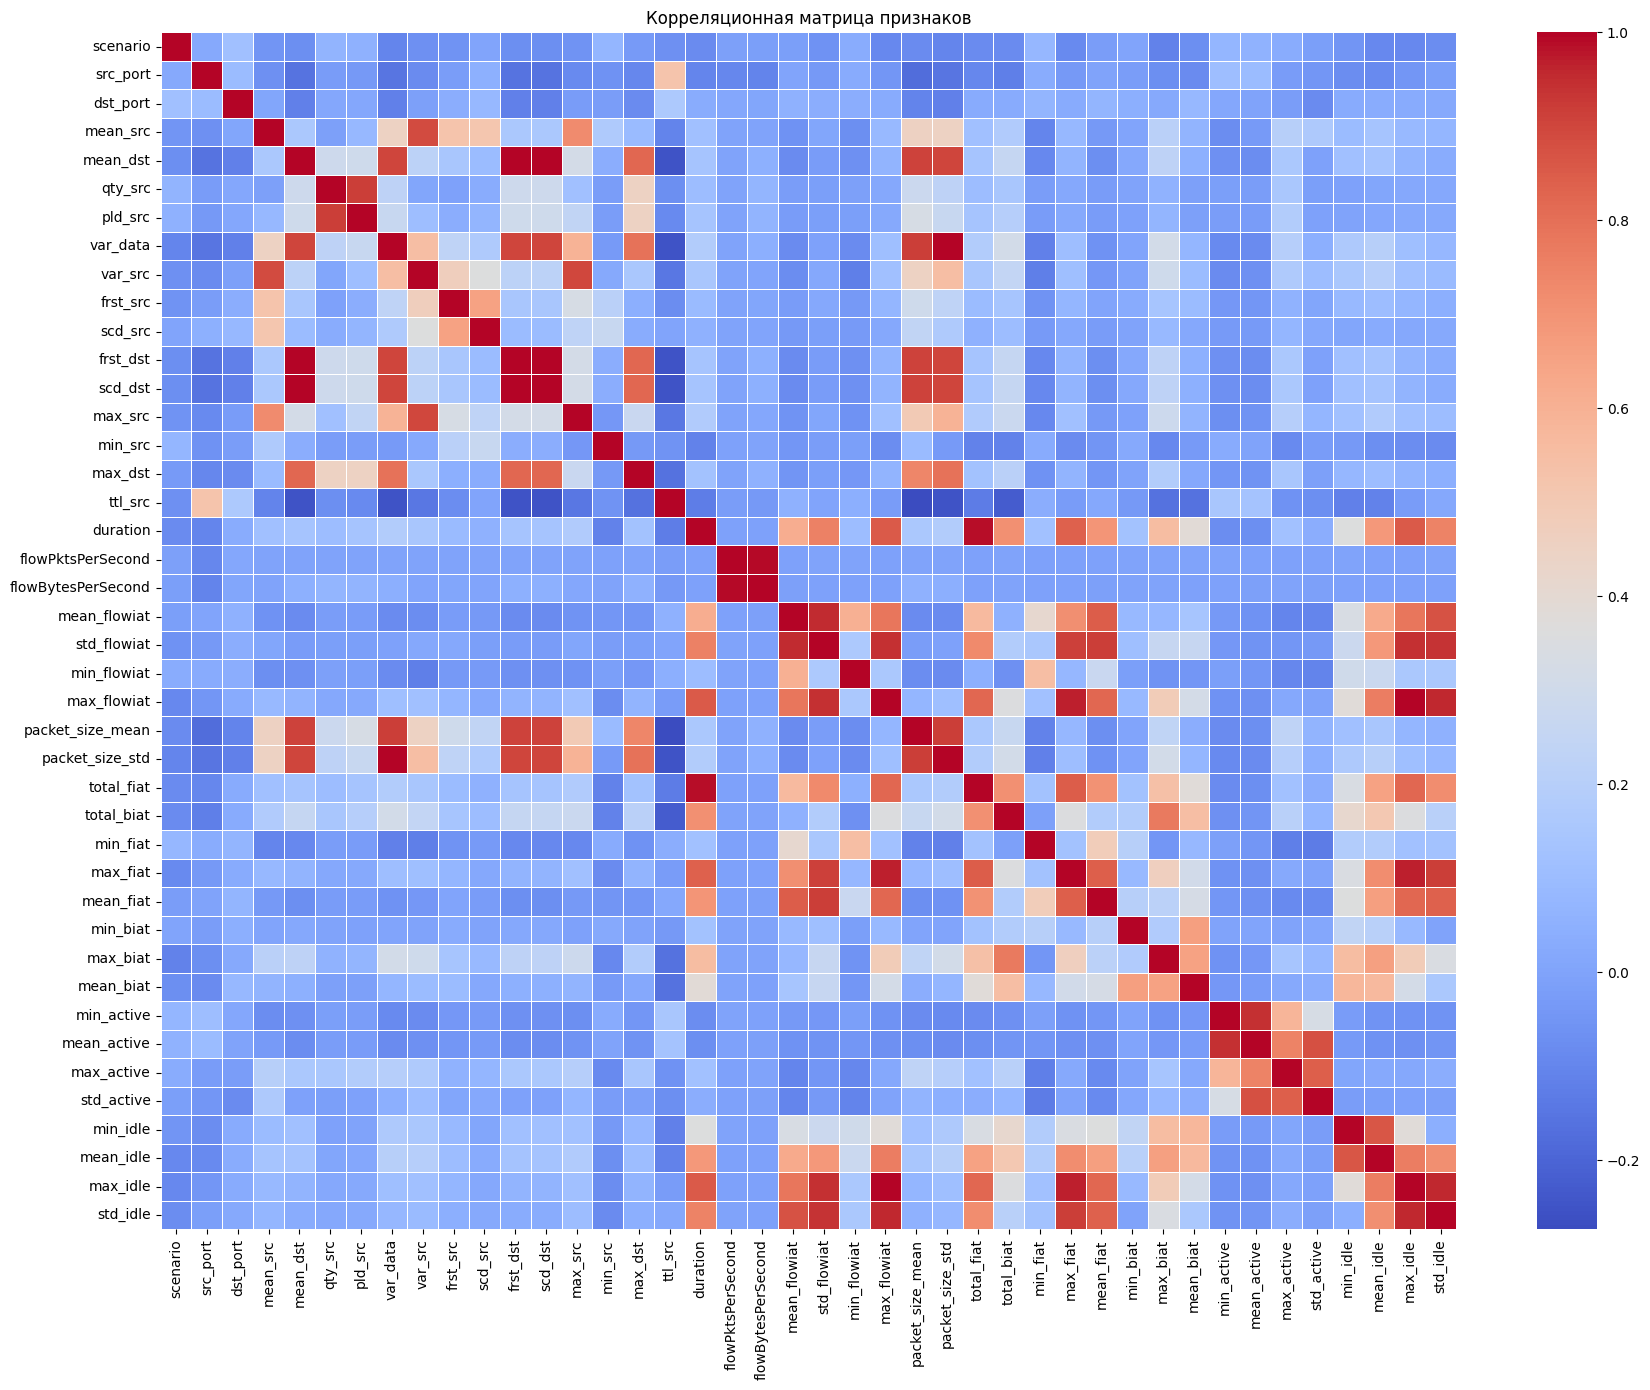

In [59]:
import seaborn as sns
import numpy as np

corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Корреляционная матрица признаков")
plt.tight_layout()
plt.show()


# Выбросы

In [60]:
# Только числовые колонки
numeric_cols = df.select_dtypes(include=np.number).columns

# Словарь для хранения количества выбросов на признак
outlier_counts = {}

# Метод 4 сигм: |x - μ| > 4σ
for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()
    outliers = df[(df[col] - mean).abs() > 3 * std]
    outlier_counts[col] = len(outliers)

# Преобразуем в DataFrame для удобства просмотра
outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)

print(outlier_df)

                    Outlier Count
min_src                       305
mean_active                   225
min_active                    225
min_idle                      218
frst_src                      217
mean_src                      213
mean_idle                     198
duration                      160
total_fiat                    154
total_biat                    141
scd_src                       130
packet_size_mean              127
std_active                    126
mean_biat                     121
max_flowiat                   113
max_idle                      113
mean_fiat                     112
mean_dst                      110
scd_dst                       110
frst_dst                      110
max_fiat                      107
std_idle                      105
var_data                       99
packet_size_std                99
std_flowiat                    97
mean_flowiat                   97
var_src                        85
max_biat                       79
min_fiat      

Выбросы решили не обрабатывать так как они не слишком многочисленны, а трафик разношерстный.

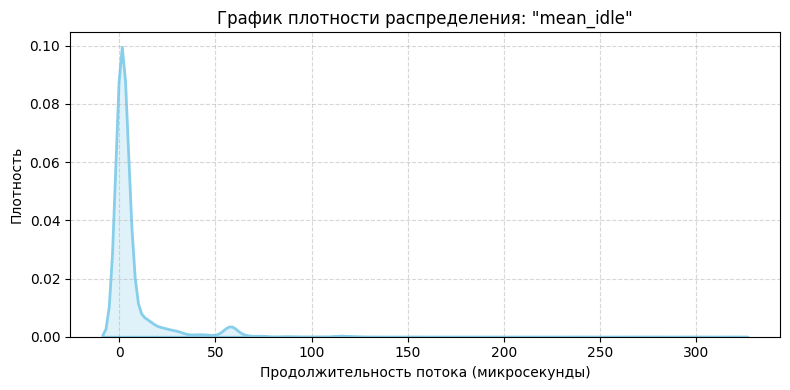

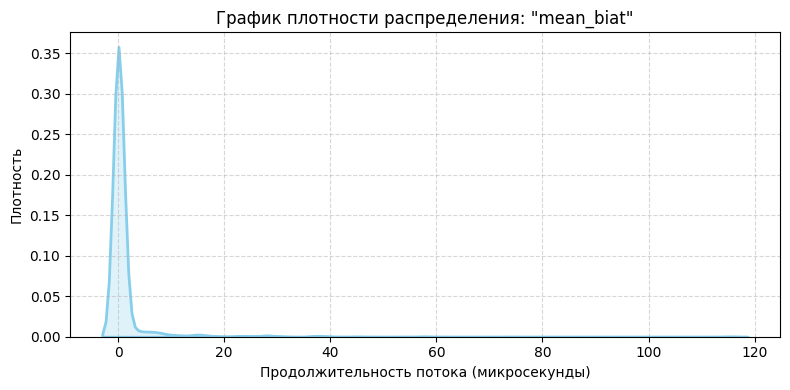

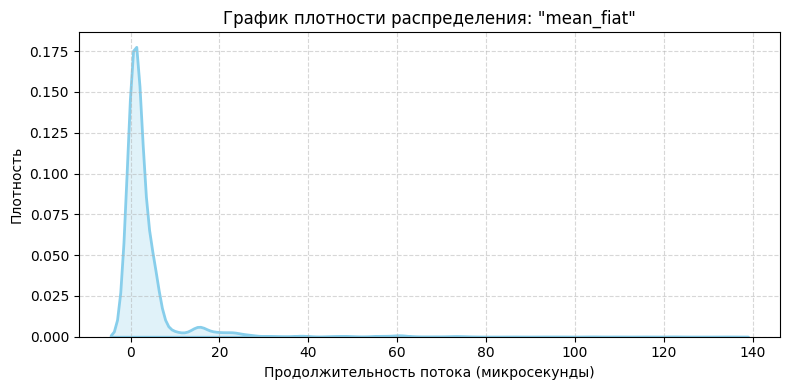

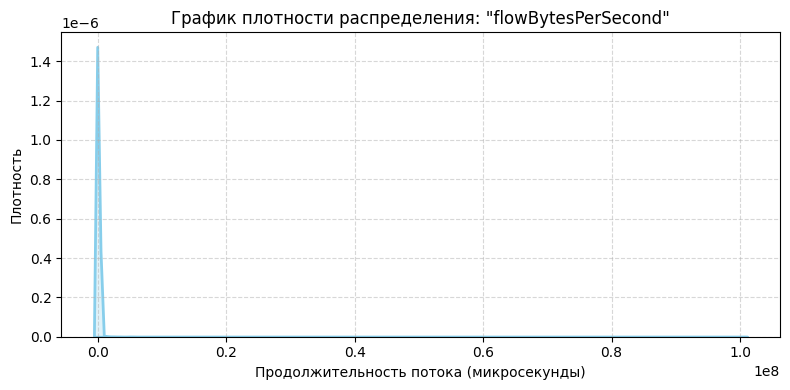

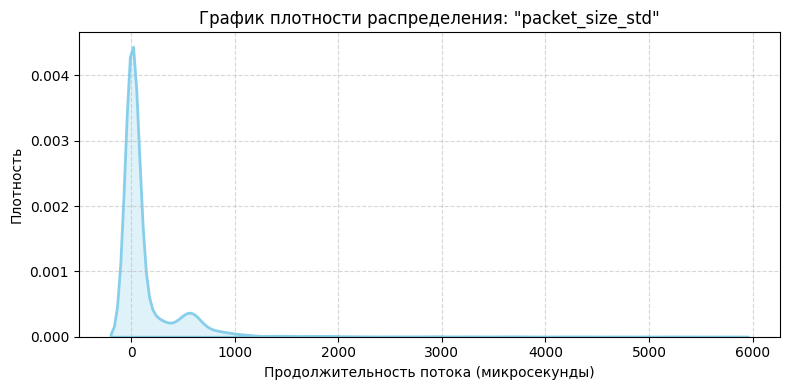

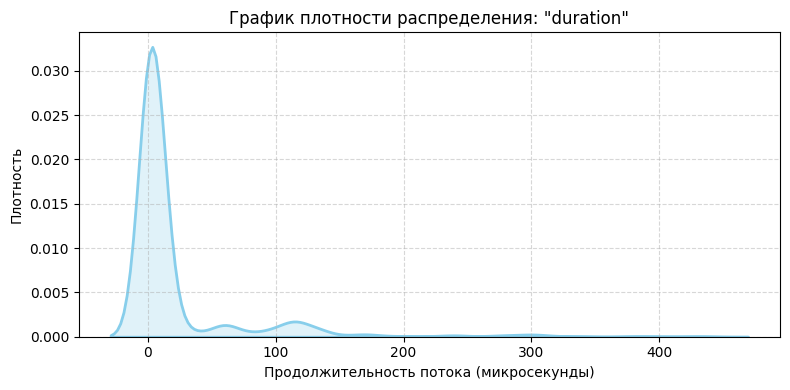

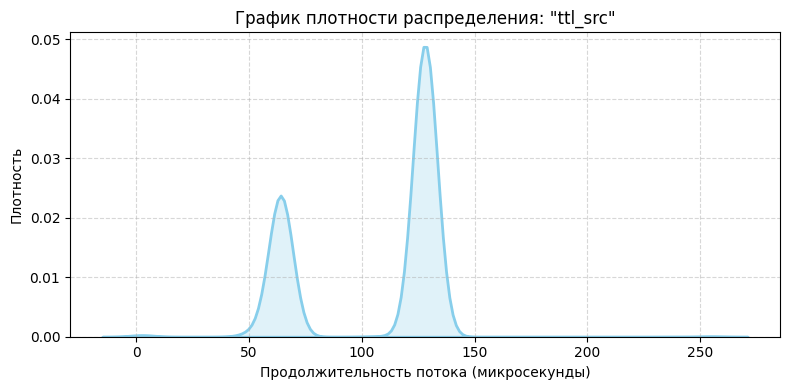

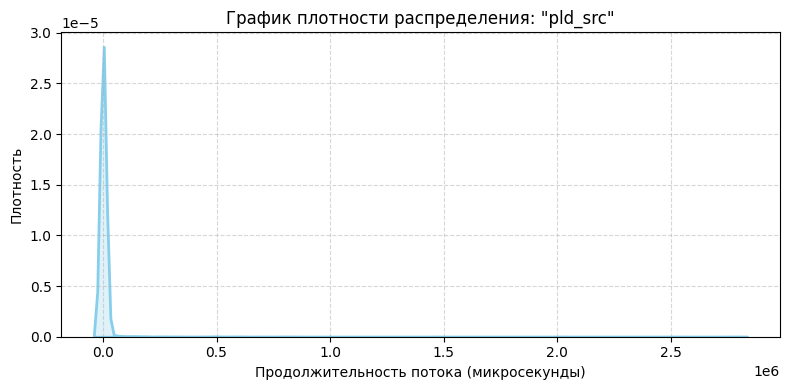

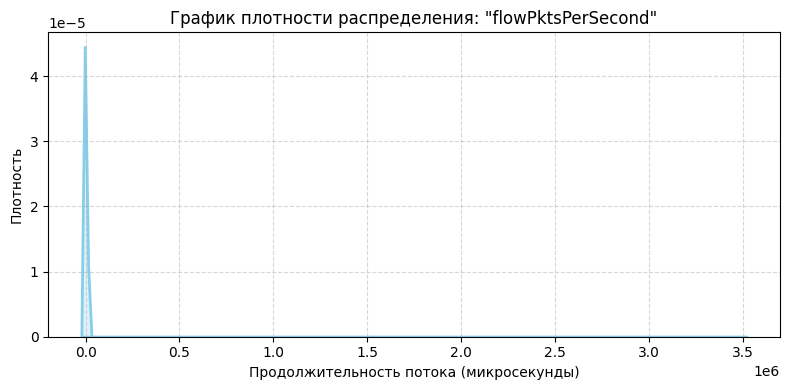

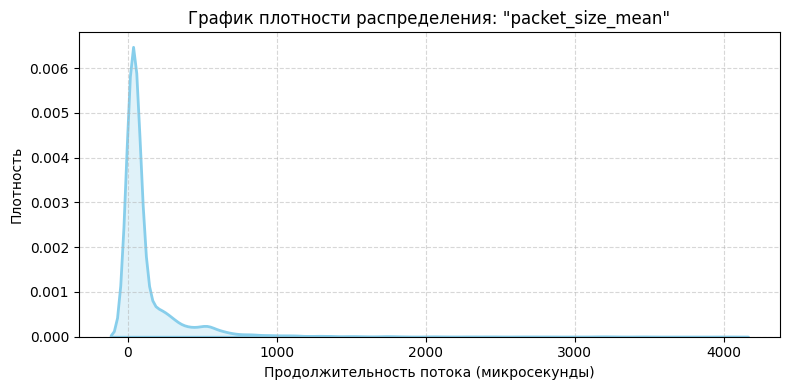

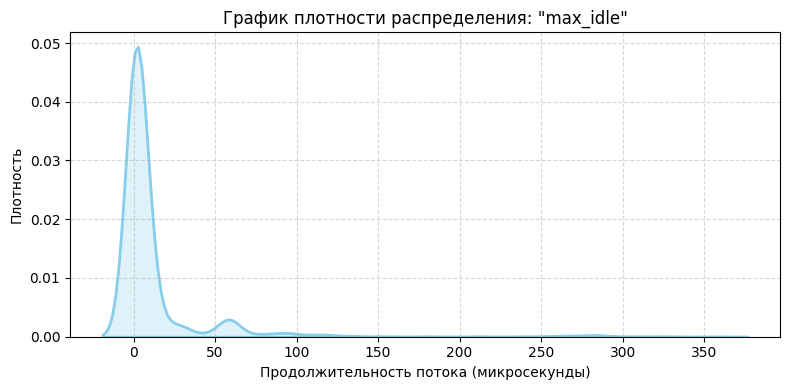

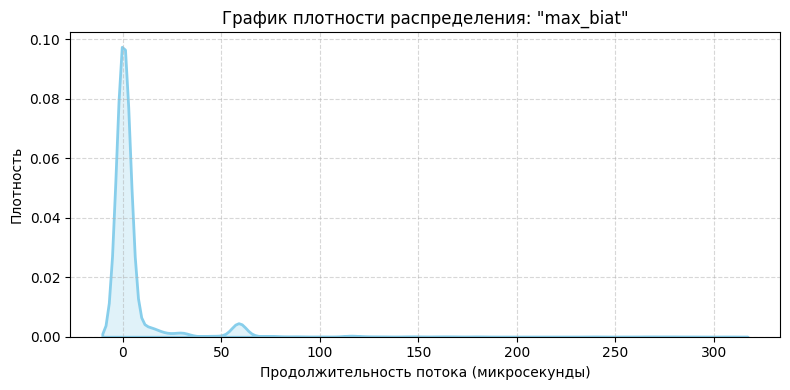

In [61]:

for col in df[important_features]:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=df[col], fill=True, color='skyblue', linewidth=2)

    plt.title(f'График плотности распределения: "{col}"')
    plt.xlabel('Продолжительность потока (микросекунды)')
    plt.ylabel('Плотность')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



# Обработка данных
## Заполнение пропусков

In [62]:
na_columns = df.columns[df.isna().any()].tolist()

for col in na_columns:
    median = df[col].median()
    df[col] = df[col].fillna(median)

print(df.isna().sum().sum())

0


## Балансирование классов

In [63]:
target_count = 900
scenarios_to_reduce = [1, 9]

# Разделим на редуцируемые и остальные
reduced_parts = []
for scenario in scenarios_to_reduce:
    part = df[df['scenario'] == scenario].sample(n=target_count, random_state=42)
    reduced_parts.append(part)

# Остальные сценарии оставим как есть
other = df[~df['scenario'].isin(scenarios_to_reduce)]

# Объединим всё вместе
df = pd.concat(reduced_parts + [other], ignore_index=True)

# Проверим новый баланс
print(df['scenario'].value_counts())
print("\nlabel distribution:\n", df['label'].value_counts())

scenario
1     900
9     900
6     783
7     734
3     292
5     165
2     124
10     83
Name: count, dtype: int64

label distribution:
 label
Non-VPN    3317
VPN         664
Name: count, dtype: int64


C:\Users\Макс\AppData\Local\Temp\ipykernel_5780\2256995305.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x='scenario_name', palette='muted', order=sorted(df2['scenario_name'].unique()))


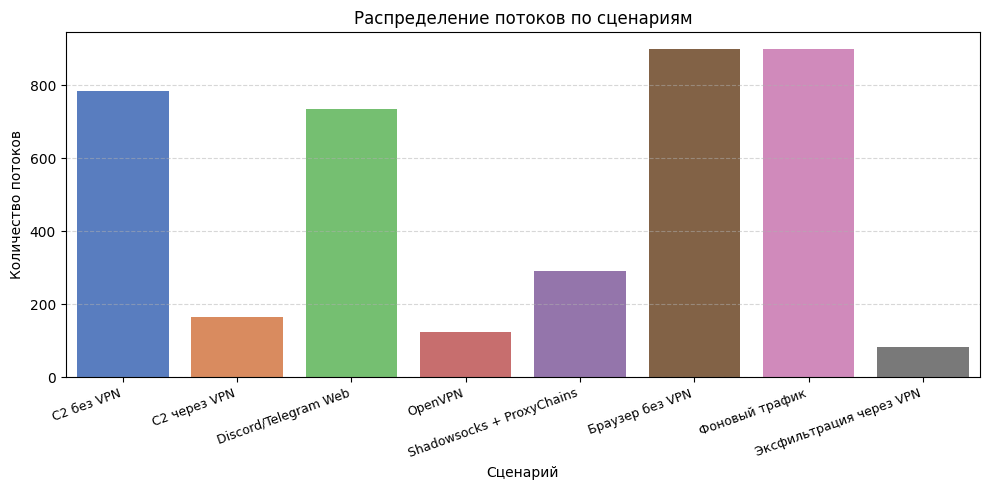

In [64]:
scenario_names = {
    1: "Браузер без VPN",
    2: "OpenVPN",
    3: "Shadowsocks + ProxyChains",
    4: "Shadowsocks (обход DPI)",
    5: "C2 через VPN",
    6: "C2 без VPN",
    7: "Discord/Telegram Web",
    9: "Фоновый трафик",
    10: "Экcфильтрация через VPN"
}

df2 = pd.DataFrame()

df2['scenario_name'] = df['scenario'].map(scenario_names)


plt.figure(figsize=(10, 5))
sns.countplot(data=df2, x='scenario_name', palette='muted', order=sorted(df2['scenario_name'].unique()))
plt.title('Распределение потоков по сценариям')
plt.xlabel('Сценарий')
plt.ylabel('Количество потоков')
plt.xticks(rotation=20, ha='right', fontsize=9)  # угол и размер шрифта
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


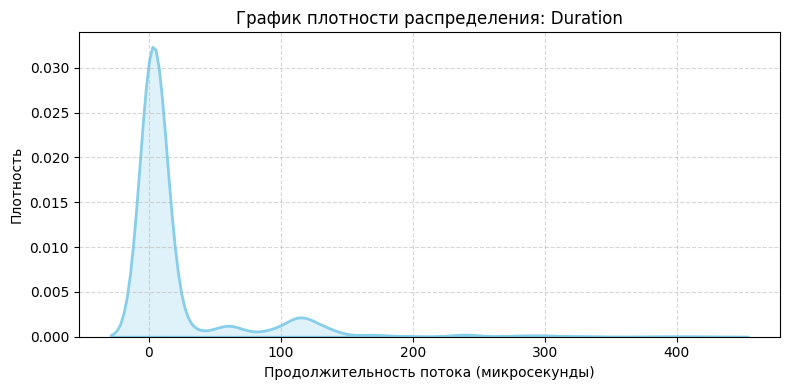

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='duration', fill=True, color='skyblue', linewidth=2)

plt.title('График плотности распределения: Duration')
plt.xlabel('Продолжительность потока (микросекунды)')
plt.ylabel('Плотность')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Маштабирование

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['label', 'scenario']))


In [68]:
from sklearn.model_selection import train_test_split
df['label'] = df['label'].map({'Non-VPN': 0, 'VPN': 1})

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)


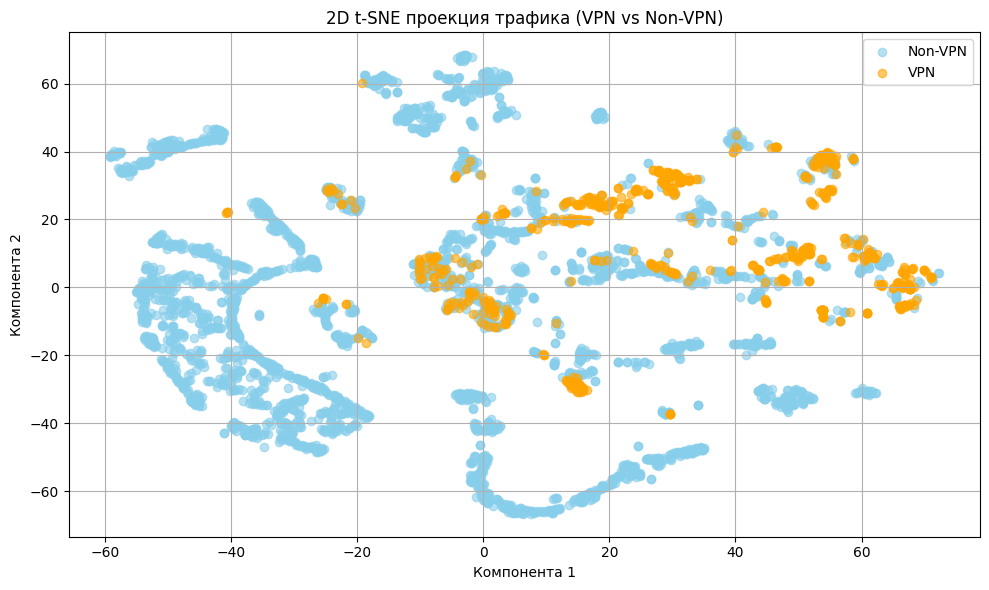

In [69]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_embedded[y == 0, 0], X_embedded[y == 0, 1], c='skyblue', label='Non-VPN', alpha=0.6)
plt.scatter(X_embedded[y == 1, 0], X_embedded[y == 1, 1], c='orange', label='VPN', alpha=0.6)
plt.title("2D t-SNE проекция трафика (VPN vs Non-VPN)")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Обучение моделей
## LogisticRegression

Fitting 5 folds for each of 704 candidates, totalling 3520 fits
Best F1 Score (CV): 0.7320812686014198
Best Params: {'C': 100, 'class_weight': None, 'fit_intercept': True, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       664
           1       0.78      0.62      0.69       133

    accuracy                           0.91       797
   macro avg       0.85      0.79      0.82       797
weighted avg       0.90      0.91      0.90       797



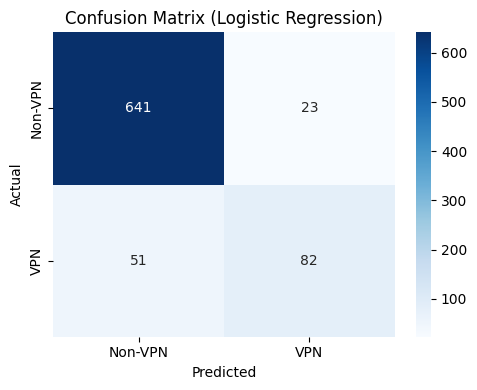

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

# Расширенная сетка гиперпараметров
param_grid_lr = {
    'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 500, 1000, 2000],
    'fit_intercept': [True, False],
    'class_weight': [None, 'balanced']
}

# Стратифицированная кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Оптимизация по F1-метрике
f1 = make_scorer(f1_score, average='binary')

# GridSearchCV
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, scoring=f1, cv=cv, n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

# Лучшие параметры и F1
print("Best F1 Score (CV):", grid_lr.best_score_)
print("Best Params:", grid_lr.best_params_)

# Предсказания на тесте
y_pred = grid_lr.predict(X_test)

# Классификационный отчёт
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.tight_layout()
plt.show()


## Random forest

In [19]:
X_scaled_2 = StandardScaler().fit_transform(
    df.drop(columns=['label', 'scenario', 'dst_port'])
)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_scaled_2, y, test_size=0.2, stratify=y, random_state=42
)

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Расширенная сетка гиперпараметров
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_rf_2 = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Обучение
grid_rf.fit(X_train, y_train)
grid_rf_2.fit(X_train_2, y_train_2)

# Лучшая модель
best_rf = grid_rf.best_estimator_
best_rf_2 = grid_rf_2.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


NameError: name 'X_train_2' is not defined

1Best F1 Score (CV): 0.8837537563777357
1Best Params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Classification Report (Test1):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       664
           1       0.95      0.83      0.89       133

    accuracy                           0.96       797
   macro avg       0.96      0.91      0.93       797
weighted avg       0.96      0.96      0.96       797

2Best F1 Score (CV): 0.8577482586732701
2Best Params: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Classification Report (Test2):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       664
           1       0.95      0.77      0.85       133

    accuracy                           0.96       797
   macro avg       0.96      0.88      0.91       797
weighted av

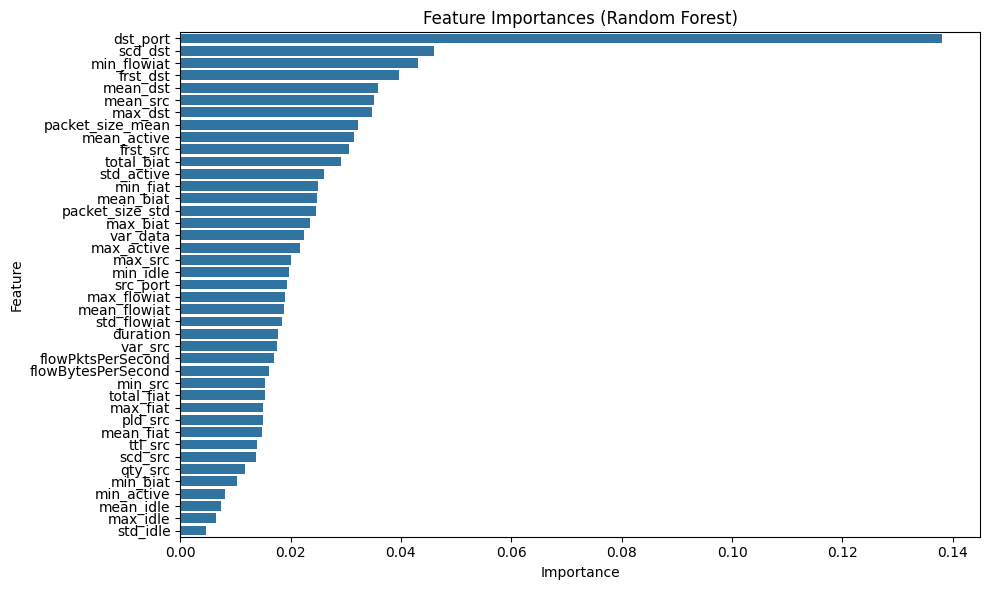

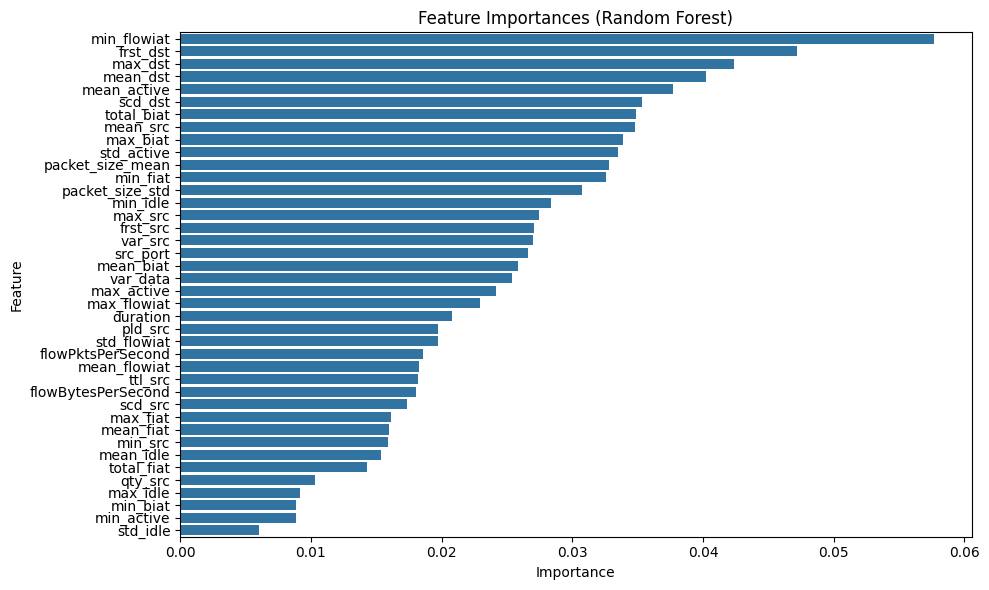

In [21]:
# Предсказания и отчёт
y_pred = best_rf.predict(X_test)
y_pred_2 = best_rf_2.predict(X_test_2)

print("1Best F1 Score (CV):", grid_rf.best_score_)
print("1Best Params:", grid_rf.best_params_)
print("\nClassification Report (Test1):")
print(classification_report(y_test, y_pred))

# Важность признаков
importances = best_rf.feature_importances_
# feature_names = df.drop(columns=["label", "scenario"]).columns
feature_names = df.drop(columns=["label", "scenario"]).columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("2Best F1 Score (CV):", grid_rf_2.best_score_)
print("2Best Params:", grid_rf_2.best_params_)
print("\nClassification Report (Test2):")
print(classification_report(y_test, y_pred_2))

# Важность признаков
importances_2 = best_rf_2.feature_importances_
# feature_names = df.drop(columns=["label", "scenario"]).columns
feature_names_2 = df.drop(columns=["label", "scenario", 'dst_port']).columns
feat_imp_2 = pd.Series(importances_2, index=feature_names_2).sort_values(ascending=False)

# Визуализация 
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_2, y=feat_imp_2.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

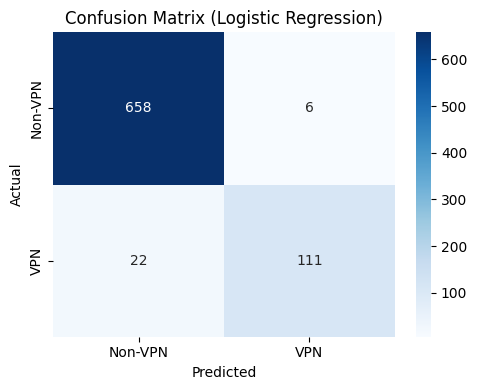

In [22]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.tight_layout()
plt.show()

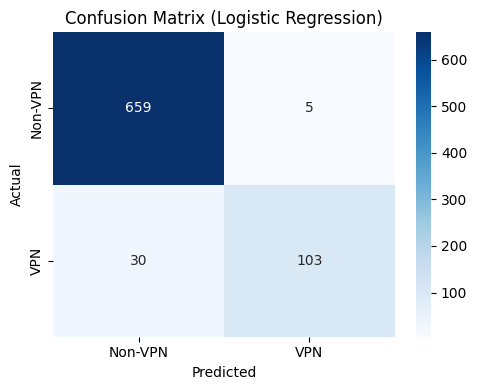

In [23]:
# Матрица ошибок
cm_2 = confusion_matrix(y_test_2, y_pred_2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.tight_layout()
plt.show()

## XGboost

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


C:\Users\Макс\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [14:10:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best F1 Score (CV): 0.8972195777127723
Best Params: {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.8}

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       664
           1       0.96      0.86      0.91       133

    accuracy                           0.97       797
   macro avg       0.97      0.93      0.95       797
weighted avg       0.97      0.97      0.97       797



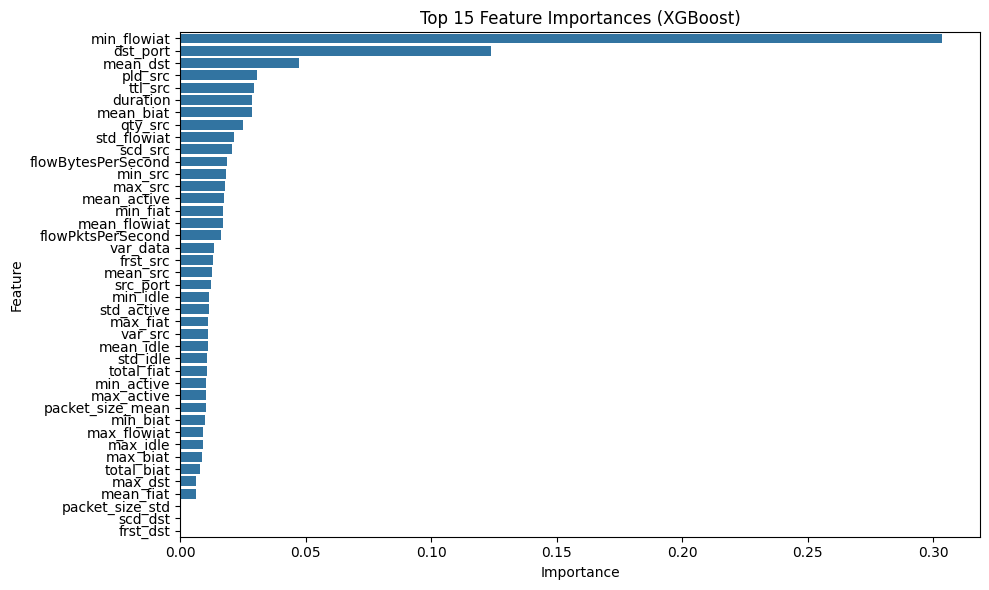

In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Сетка гиперпараметров
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'gamma': [0, 1],
    'scale_pos_weight': [1, 5]  # может помочь при дисбалансе классов
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_xgb = GridSearchCV(xgb, param_grid_xgb, scoring='f1', cv=5, n_jobs=-1, verbose=1)

# Обучение
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

# Предсказания
y_pred_xgb = best_xgb.predict(X_test)

# Оценка
print("Best F1 Score (CV):", grid_xgb.best_score_)
print("Best Params:", grid_xgb.best_params_)
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_xgb))

# Важность признаков
importances_xgb = best_xgb.feature_importances_
feature_names = df.drop(columns=["label", "scenario"]).columns
feat_imp_xgb = pd.Series(importances_xgb, index=feature_names).sort_values(ascending=False)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_xgb, y=feat_imp_xgb.index)
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


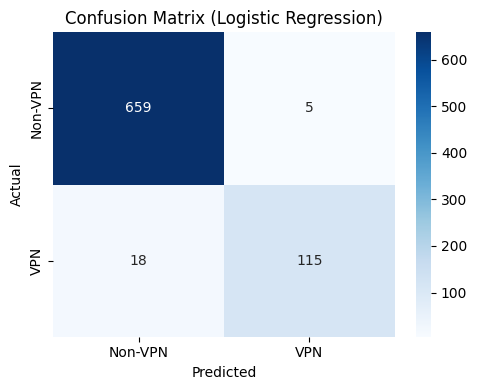

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.tight_layout()
plt.show()

## TabNet

In [34]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np
import torch

# Табличные данные
X_tabnet = X_scaled.astype(np.float32)  # важно: float32
y_tabnet = y.values  # метки

# Разбивка
X_train_tn, X_test_tn, y_train_tn, y_test_tn = train_test_split(
    X_tabnet, y_tabnet, test_size=0.2, stratify=y_tabnet, random_state=42
)

weights = class_weight.compute_class_weight(class_weight="balanced", classes=np.unique(y_train_tn), y=y_train_tn)
weights = dict(enumerate(weights))

# Обучение
tabnet = TabNetClassifier(
    seed=42,
    verbose=1,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax'
)

tabnet.fit(
    X_train=X_train_tn, y_train=y_train_tn,
    eval_set=[(X_test_tn, y_test_tn)],
    eval_name=['valid'],
    eval_metric=['balanced_accuracy'],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=128
)

# Оценка
y_pred_tn = tabnet.predict(X_test_tn)
print(classification_report(y_test_tn, y_pred_tn))

C:\Users\Макс\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.65891 | valid_balanced_accuracy: 0.56315 |  0:00:00s
epoch 1  | loss: 0.40437 | valid_balanced_accuracy: 0.55789 |  0:00:00s
epoch 2  | loss: 0.33639 | valid_balanced_accuracy: 0.57669 |  0:00:00s
epoch 3  | loss: 0.30507 | valid_balanced_accuracy: 0.6451  |  0:00:01s
epoch 4  | loss: 0.27389 | valid_balanced_accuracy: 0.72781 |  0:00:01s
epoch 5  | loss: 0.24938 | valid_balanced_accuracy: 0.7684  |  0:00:01s
epoch 6  | loss: 0.23435 | valid_balanced_accuracy: 0.78419 |  0:00:02s
epoch 7  | loss: 0.2365  | valid_balanced_accuracy: 0.80675 |  0:00:02s
epoch 8  | loss: 0.22711 | valid_balanced_accuracy: 0.79396 |  0:00:02s
epoch 9  | loss: 0.22597 | valid_balanced_accuracy: 0.80149 |  0:00:03s
epoch 10 | loss: 0.22923 | valid_balanced_accuracy: 0.79471 |  0:00:03s
epoch 11 | loss: 0.22174 | valid_balanced_accuracy: 0.79546 |  0:00:03s
epoch 12 | loss: 0.22254 | valid_balanced_accuracy: 0.79546 |  0:00:03s
epoch 13 | loss: 0.20771 | valid_balanced_accuracy: 0.79997 |  0

C:\Users\Макс\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
cm = confusion_matrix(y_test_tn, y_pred_tn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (MLP)')
plt.tight_layout()
plt.show()

## MLP

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, ReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import class_weight
import numpy as np

# Подготовка данных
X_mlp = X_scaled.astype(np.float32)
y_mlp = y.values

X_train, X_test, y_train, y_test = train_test_split(
    X_mlp, y_mlp, test_size=0.2, stratify=y_mlp, random_state=42
)

weights = class_weight.compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
weights = dict(enumerate(weights))

# Резидуальный блок
def residual_block(x, units, dropout_rate, l2_reg=1e-4):
    shortcut = x
    if x.shape[-1] != units:
        shortcut = Dense(units, kernel_regularizer=l2(l2_reg))(shortcut)
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut])
    x = ReLU()(x)
    x = Dropout(dropout_rate)(x)
    return x

# Сборка модели

input_layer = Input(shape=(X_train.shape[1],))
x = residual_block(input_layer, 128, 0.3)
x = residual_block(x, 64, 0.3)
x = residual_block(x, 32, 0.2)
x = residual_block(x, 16, 0.1)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['Precision', 'Recall']
)


# Обучение
es = EarlyStopping(monitor='val_recall', mode='max', patience=15, restore_best_weights=True, verbose=1)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=128,
    class_weight=weights,
    callbacks=[es],
    verbose=1
)

# Оценка
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))


Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - Precision: 0.2282 - Recall: 0.0828 - loss: 1.3883 - val_Precision: 0.2895 - val_Recall: 0.2136 - val_loss: 0.7058
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Precision: 0.3306 - Recall: 0.1492 - loss: 1.0428 - val_Precision: 0.3670 - val_Recall: 0.3883 - val_loss: 0.6793
Epoch 3/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - Precision: 0.3636 - Recall: 0.2353 - loss: 0.7034

C:\Users\Макс\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: Precision,Recall,loss,val_Precision,val_Recall,val_loss
  current = self.get_monitor_value(logs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Precision: 0.3109 - Recall: 0.1935 - loss: 0.9071 - val_Precision: 0.4167 - val_Recall: 0.4854 - val_loss: 0.6547
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.2996 - Recall: 0.2546 - loss: 0.8658 - val_Precision: 0.4821 - val_Recall: 0.5243 - val_loss: 0.6352
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.3460 - Recall: 0.3062 - loss: 0.8435 - val_Precision: 0.4553 - val_Recall: 0.5437 - val_loss: 0.6177
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Precision: 0.3378 - Recall: 0.3934 - loss: 0.7809 - val_Precision: 0.4545 - val_Recall: 0.5340 - val_loss: 0.6005
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.2902 - Recall: 0.3598 - loss: 0.7880 - val_Precision: 0.4198 - val_Recall: 0.5340 - val_loss: 0.5836
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.3253 - Recall: 0.4384 - loss: 0.6842 - val_Precision: 0.4485 - val_Recall: 0.5922 - val_loss: 0.5670
Epoch 9/30

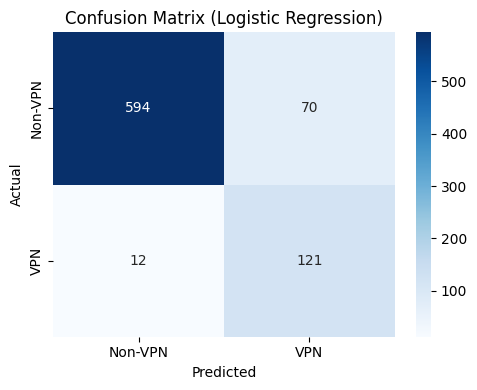

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (MLP)')
plt.tight_layout()
plt.show()

## Stacking

In [63]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Базовые модели
base_learners = [
    ('lr', LogisticRegression(C=100, penalty='l1', solver='liblinear', max_iter=500)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, subsample=0.8, use_label_encoder=False, eval_metric='logloss'))
]

# Мета-learner
meta_learner = LogisticRegression()

# Стекинг
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=True  # можно True, если хочешь добавить исходные признаки на второй уровень
)

# Обучение
stacking_model.fit(X_train, y_train)

# Оценка
y_pred = stacking_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       664
           1       0.96      0.86      0.90       133

    accuracy                           0.97       797
   macro avg       0.96      0.92      0.94       797
weighted avg       0.97      0.97      0.97       797



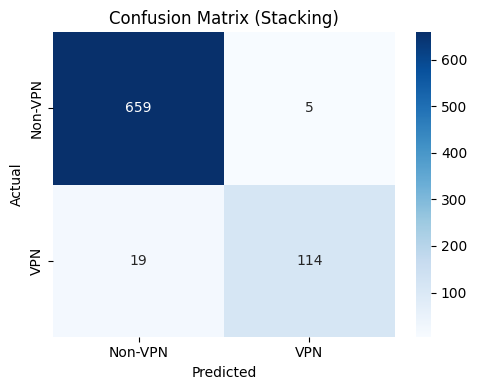

In [66]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Stacking)')
plt.tight_layout()
plt.show()

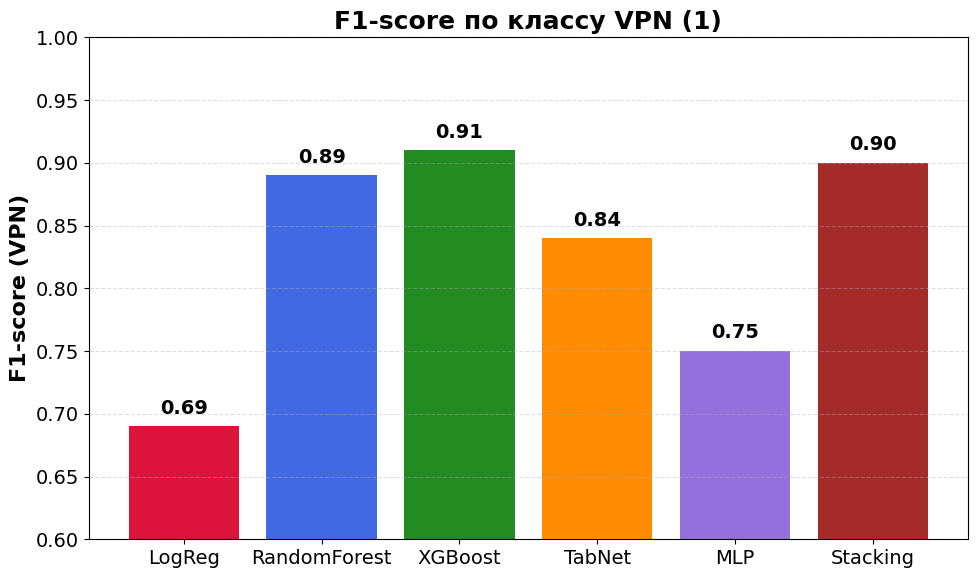

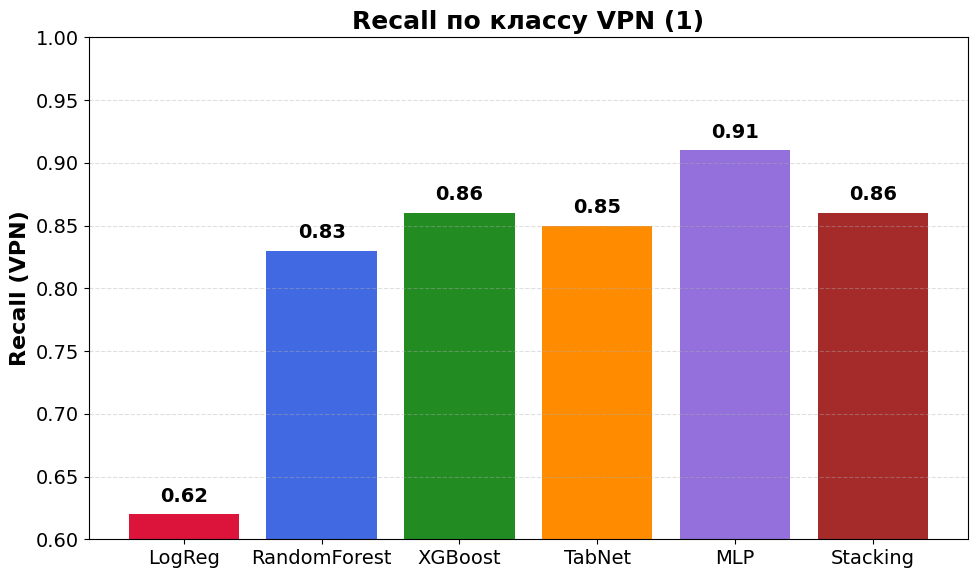

In [1]:
import matplotlib.pyplot as plt

# Данные
models = ['LogReg', 'RandomForest', 'XGBoost', 'TabNet', 'MLP', 'Stacking']
f1_scores = [0.69, 0.89, 0.91, 0.84, 0.75, 0.90]
recalls = [0.62, 0.83, 0.86, 0.85, 0.91, 0.86]
colors = ['crimson', 'royalblue', 'forestgreen', 'darkorange', 'mediumpurple', 'brown']

# Установим общий стиль шрифтов
plt.rcParams.update({
    'font.size': 14,             # общий размер шрифта
    'axes.titlesize': 18,        # размер заголовков
    'axes.labelsize': 16,        # подписи осей
    'xtick.labelsize': 14,       # подписи по X
    'ytick.labelsize': 14,       # подписи по Y
})

# График F1-score
plt.figure(figsize=(10, 6))
bars1 = plt.bar(models, f1_scores, color=colors)
plt.ylim(0.6, 1.0)
plt.title("F1-score по классу VPN (1)", weight='bold')
plt.ylabel("F1-score (VPN)", weight='bold')
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', fontsize=14, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# График Recall
plt.figure(figsize=(10, 6))
bars2 = plt.bar(models, recalls, color=colors)
plt.ylim(0.6, 1.0)
plt.title("Recall по классу VPN (1)", weight='bold')
plt.ylabel("Recall (VPN)", weight='bold')
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', fontsize=14, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


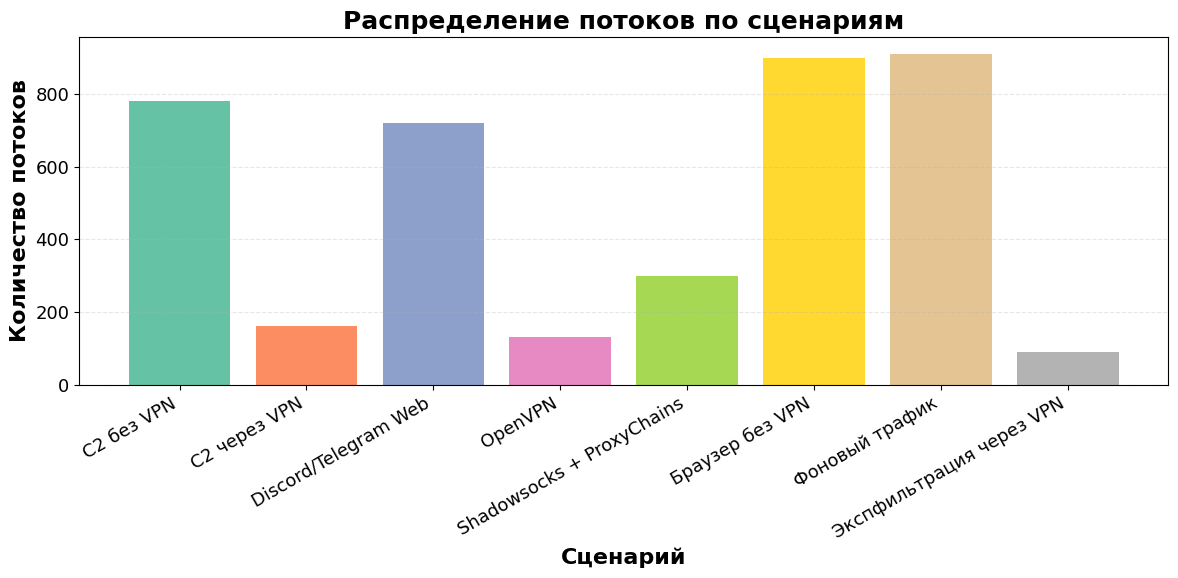

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Данные
scenarios = [
    'C2 без VPN', 'C2 через VPN', 'Discord/Telegram Web', 'OpenVPN',
    'Shadowsocks + ProxyChains', 'Браузер без VPN', 'Фоновый трафик', 'Экспфильтрация через VPN'
]
counts = [780, 160, 720, 130, 300, 900, 910, 90]
colors = sns.color_palette("Set2", n_colors=len(scenarios))

# Обновление стиля
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13
})

# Построение графика
plt.figure(figsize=(12, 6))
bars = plt.bar(scenarios, counts, color=colors)

plt.title("Распределение потоков по сценариям", weight='bold')
plt.ylabel("Количество потоков", weight='bold')
plt.xlabel("Сценарий", weight='bold')

# Угол подписей
plt.xticks(rotation=20, ha='right')

# Подписи над столбцами
# for bar in bars:
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, height + 15, str(height), 
#              ha='center', va='bottom', fontsize=13, weight='bold')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()
